In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("oddrationale/mnist-in-csv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mnist-in-csv' dataset.
Path to dataset files: /kaggle/input/mnist-in-csv


In [ ]:
!ls /root/.cache/kagglehub/datasets/oddrationale/mnist-in-csv/versions/2

ls: cannot access '/root/.cache/kagglehub/datasets/oddrationale/mnist-in-csv/versions/2': No such file or directory


In [ ]:
# move path to content folder
!mv /root/.cache/kagglehub/datasets/oddrationale/mnist-in-csv/versions/2 /content/mnist_train.csv

mv: cannot stat '/root/.cache/kagglehub/datasets/oddrationale/mnist-in-csv/versions/2': No such file or directory


In [ ]:
# /content/mnist_train

In [ ]:
data = pd.read_csv('/content/mnist_dataset/mnist_train.csv')

In [ ]:
data.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data_array = np.array(data)
m, n = data_array.shape
np.random.shuffle(data_array)

In [ ]:
print(m, n)

60000 785


In [ ]:
train_data = data_array[0:int(0.8*m), :]
val_data = data_array[int(0.8*m):m, :]

X_train = train_data[:, 1:].T
X_train = X_train / 255.0
Y_train = train_data[:, 0]

X_val = val_data[:, 1:].T
X_val = X_val / 255.0
Y_val = val_data[:, 0]

In [ ]:
print(X_val.shape)
print(Y_val.shape)
print(X_train.shape)
print(Y_train.shape)

(784, 12000)
(12000,)
(784, 48000)
(48000,)


In [ ]:
def initialize_parameters():
  W1 = np.random.rand(10, 784) - 0.5
  B1 = np.random.rand(10, 1) - 0.5
  W2 = np.random.rand(10, 10) - 0.5
  B2 = np.random.rand(10, 1) - 0.5
  return W1, B1, W2, B2

def ReLu(Z):
  return np.maximum(Z, 0)

def softmax(Z):
  A = np.exp(Z) / sum(np.exp(Z))
  return A

def forward_propagation(W1, B1, W2, B2, X):
  Z1 = W1.dot(X) + B1
  A1 = ReLu(Z1)
  Z2 = W2.dot(A1) + B2
  A2 = softmax(Z2)
  return Z1, A1, Z2, A2

def one_hot_converter(Y):
  one_hot_Y = np.zeros((Y.size, Y.max() + 1))
  one_hot_Y[np.arange(Y.size), Y] = 1
  return one_hot_Y.T

def back_propagation(W1, B1, W2, B2, Z1, A1, Z2, A2, Y, X):
  one_hot_Y = one_hot_converter(Y)
  dz2 = A2 - one_hot_Y
  dw2 = 1 / m * dz2.dot(A1.T)
  db2 = 1 / m * np.sum(dz2)
  dz1 = W2.T.dot(dz2) * (Z1 > 0)
  dw1 = 1 / m * dz1.dot(X.T)
  db1 = 1 / m * np.sum(dz1)
  return dw1, db1, dw2, db2

def update_parameters(W1, B1, W2, B2,dw1, db1, dw2, db2, learning_rate):
  W1 = W1 - learning_rate * dw1
  B1 = B1 - learning_rate * db1
  W2 = W2 - learning_rate * dw2
  B2 = B2 - learning_rate * db2
  return W1, B1, W2, B2

def get_predictions(A2):
  return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
  return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, learning_rate, iterations):
  W1, B1, W2, B2 = initialize_parameters()

  for i in range(iterations):
    Z1, A1, Z2, A2 = forward_propagation(W1, B1, W2, B2, X)
    dw1, db1, dw2, db2 = back_propagation(W1, B1, W2, B2, Z1, A1, Z2, A2, Y, X)
    W1, B1, W2, B2 = update_parameters(W1, B1, W2, B2,dw1, db1, dw2, db2, learning_rate)
    if i % 20 == 0:
      print("Iteration: ", i)
      predictions = get_predictions(A2)
      print(get_accuracy(predictions, Y))
  return W1, B1, W2, B2

In [ ]:
W1, B1, W2, B2 = gradient_descent(X_train, Y_train, 0.10, 1000)

Iteration:  0
0.061625
Iteration:  20
0.190875
Iteration:  40
0.3029791666666667
Iteration:  60
0.4114375
Iteration:  80
0.48560416666666667
Iteration:  100
0.5506041666666667
Iteration:  120
0.6037916666666666
Iteration:  140
0.6435416666666667
Iteration:  160
0.6742916666666666
Iteration:  180
0.69825
Iteration:  200
0.7170833333333333
Iteration:  220
0.7327291666666667
Iteration:  240
0.7460208333333334
Iteration:  260
0.7570833333333333
Iteration:  280
0.7670208333333334
Iteration:  300
0.7746875
Iteration:  320
0.78125
Iteration:  340
0.7870208333333333
Iteration:  360
0.7925208333333333
Iteration:  380
0.7974583333333334
Iteration:  400
0.8015625
Iteration:  420
0.8059583333333333
Iteration:  440
0.8100833333333334
Iteration:  460
0.8138958333333334
Iteration:  480
0.8172708333333333
Iteration:  500
0.8204375
Iteration:  520
0.8232708333333333
Iteration:  540
0.8257083333333334
Iteration:  560
0.8283958333333333
Iteration:  580
0.830375
Iteration:  600
0.8326041666666667
Iteratio

Predicted label: [1]
Actual label: 1


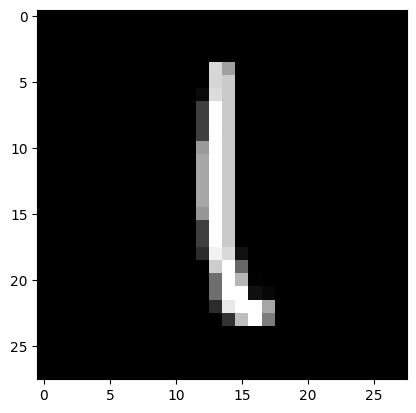

In [ ]:
val_index = 0
Z1val, A1val, Z2val, A2val = forward_propagation(W1, B1, W2, B2, X_val[:,val_index, None])
print("Predicted label:", get_predictions(A2val))
print("Actual label:", Y_val[val_index])


image_array = X_val[:,val_index].reshape((28, 28))
plt.imshow(image_array, cmap='gray')
plt.show()

In [ ]:
Z1val, A1val, Z2val, A2val = forward_propagation(W1, B1, W2, B2, X_val)
val_acc = get_accuracy(get_predictions(A2val), Y_val)
print('Validation Accuracy: ', val_acc)

Validation Accuracy:  0.8631666666666666
